# Credit Risk — Loan Default Predictor: Exploratory Data Analysis

**Dataset**: LendingClub accepted loans 2007–2018 (cleaned)  
**Target**: `default` — 1 = Charged Off / Default / Late 31-120d, 0 = Fully Paid  
**Shape**: ~1.37M rows × 84 features

---
### Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Target Variable](#3)
4. [Missing Values](#4)
5. [Numerical Features — Distributions](#5)
6. [Categorical Features — Value Counts](#6)
7. [Correlation Analysis](#7)
8. [Feature vs Target Relationships](#8)
9. [Key Insights](#9)

## 1. Setup & Data Loading <a id="1"></a>

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Optional: plotly for interactive charts
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY = True
except ImportError:
    PLOTLY = False
    print("plotly not installed — falling back to matplotlib only")

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()          # notebook/ → project root
DATA_PATH    = PROJECT_ROOT / "data" / "processed" / "loans_cleaned.parquet"

print(f"Project root : {PROJECT_ROOT}")
print(f"Data file    : {DATA_PATH}")
print(f"Exists       : {DATA_PATH.exists()}")

Project root : /Users/kongsattha/Documents/Personal Doc/PersoanlProject/Credit Risk : Loan Default Predictor
Data file    : /Users/kongsattha/Documents/Personal Doc/PersoanlProject/Credit Risk : Loan Default Predictor/data/processed/loans_cleaned.parquet
Exists       : True


In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
df.head(3)

Shape : 1,369,566 rows  ×  85 columns


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,default,loan_age_months,cr_history_months
0,3600.0,3600.0,3600.0,36,13.99,123.029999,C,C4,leadman,10.0,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0,37,185
1,24700.0,24700.0,24700.0,36,11.99,820.280029,C,C1,Engineer,10.0,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0,37,229
2,20000.0,20000.0,20000.0,60,10.78,432.660004,B,B4,truck driver,10.0,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,0,37,221


## 2. Dataset Overview <a id="2"></a>

In [3]:
# Column types summary
num_cols  = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols  = df.select_dtypes(include=["object", "category"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print(f"Numeric   : {len(num_cols)}")
print(f"Categoric : {len(cat_cols)}")
print(f"Boolean   : {len(bool_cols)}")
print()

# dtypes + non-null counts
info_df = pd.DataFrame({
    "dtype"   : df.dtypes,
    "non_null": df.notna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "nunique" : df.nunique(),
}).sort_values("null_pct", ascending=False)

info_df

Numeric   : 75
Categoric : 10
Boolean   : 0



,dtype,non_null,null_pct,nunique
loan_amnt,float32,1369566,0.0,1563
mo_sin_rcnt_rev_tl_op,float32,1369566,0.0,288
num_bc_sats,float32,1369566,0.0,52
num_actv_rev_tl,float32,1369566,0.0,52
num_actv_bc_tl,float32,1369566,0.0,34
...,...,...,...,...
application_type,object,1369566,0.0,2
collections_12_mths_ex_med,float32,1369566,0.0,15
initial_list_status,object,1369566,0.0,2
total_acc,float32,1369566,0.0,144


In [4]:
# Numeric summary statistics
df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
loan_amnt,1369566.0,14448.774414,8737.506836,500.0,1500.0,3200.0,8000.0,12000.0,20000.0,33000.0,35000.0,40000.0
funded_amnt,1369566.0,14440.101562,8733.728516,500.0,1500.0,3200.0,8000.0,12000.0,20000.0,33000.0,35000.0,40000.0
funded_amnt_inv,1369566.0,14412.804688,8739.795898,0.0,1500.0,3125.0,7900.0,12000.0,20000.0,33000.0,35000.0,40000.0
term,1369566.0,41.850951,10.304818,36.0,36.0,36.0,36.0,36.0,36.0,60.0,60.0,60.0
int_rate,1369566.0,13.279112,4.784094,5.31,5.32,6.54,9.75,12.79,16.02,22.200001,26.49,30.99
...,...,...,...,...,...,...,...,...,...,...,...,...
total_bc_limit,1369566.0,21378.515625,21186.197266,0.0,0.0,2300.0,8000.0,15100.0,27400.0,62100.0,102600.0,1105500.0
total_il_high_credit_limit,1369566.0,41646.765625,42238.6875,0.0,0.0,0.0,15500.0,31718.0,54823.0,117882.0,201221.4,2101913.0
default,1369566.0,0.21235,0.408971,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
loan_age_months,1369566.0,42.603851,19.819321,1.0,6.0,13.0,30.0,41.0,54.0,77.0,102.0,139.0


## 3. Target Variable <a id="3"></a>

Default rate : 21.23%
default
0    1078739
1     290827


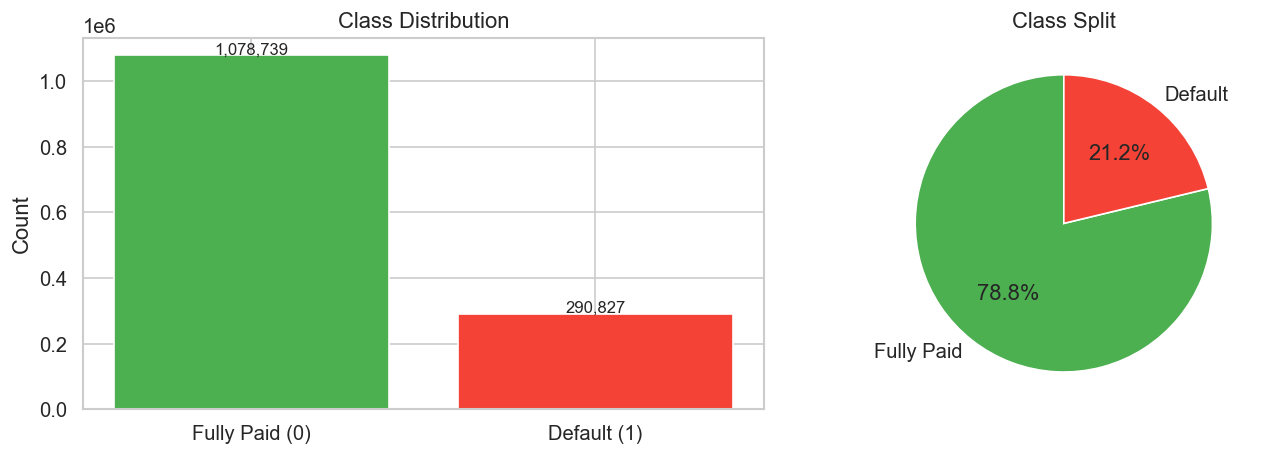

In [5]:
TARGET = "default"

counts      = df[TARGET].value_counts()
default_rate = df[TARGET].mean() * 100

print(f"Default rate : {default_rate:.2f}%")
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Fully Paid (0)", "Default (1)"],
            counts.values,
            color=["#4CAF50", "#F44336"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5000,
                 f"{val:,}", ha="center", fontsize=10)

# Default rate over time
if "issue_d" in df.columns or "issue_year" in df.columns:
    time_col = "issue_year" if "issue_year" in df.columns else "issue_d"
    rate_by_year = df.groupby(time_col)[TARGET].mean() * 100
    axes[1].plot(rate_by_year.index, rate_by_year.values, marker="o", color="#E91E63")
    axes[1].axhline(default_rate, ls="--", color="grey", label=f"Overall {default_rate:.1f}%")
    axes[1].set_title("Default Rate by Issue Year")
    axes[1].set_ylabel("Default Rate (%)")
    axes[1].set_xlabel(time_col)
    axes[1].legend()
else:
    axes[1].pie(counts.values,
                labels=["Fully Paid", "Default"],
                autopct="%1.1f%%",
                colors=["#4CAF50", "#F44336"],
                startangle=90)
    axes[1].set_title("Class Split")

plt.tight_layout()
plt.show()

## 4. Missing Values <a id="4"></a>

In [6]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]

print(f"Columns with any missing values: {len(miss_nonzero)}")
display(miss_nonzero.rename("missing_%").to_frame().style.background_gradient(cmap="Reds"))

# Heatmap of missingness for columns with > 1% missing
cols_with_miss = miss_nonzero[miss_nonzero > 1].index.tolist()
if cols_with_miss:
    fig, ax = plt.subplots(figsize=(max(10, len(cols_with_miss) * 0.5), 4))
    ax.bar(cols_with_miss, miss_nonzero[cols_with_miss], color="#EF5350")
    ax.set_title("Missing Value % (columns > 1% missing)")
    ax.set_ylabel("Missing %")
    ax.set_xlabel("Column")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No columns with >1% missing — data is very clean!")

Columns with any missing values: 0


,missing_%


No columns with >1% missing — data is very clean!


## 5. Numerical Features — Distributions <a id="5"></a>

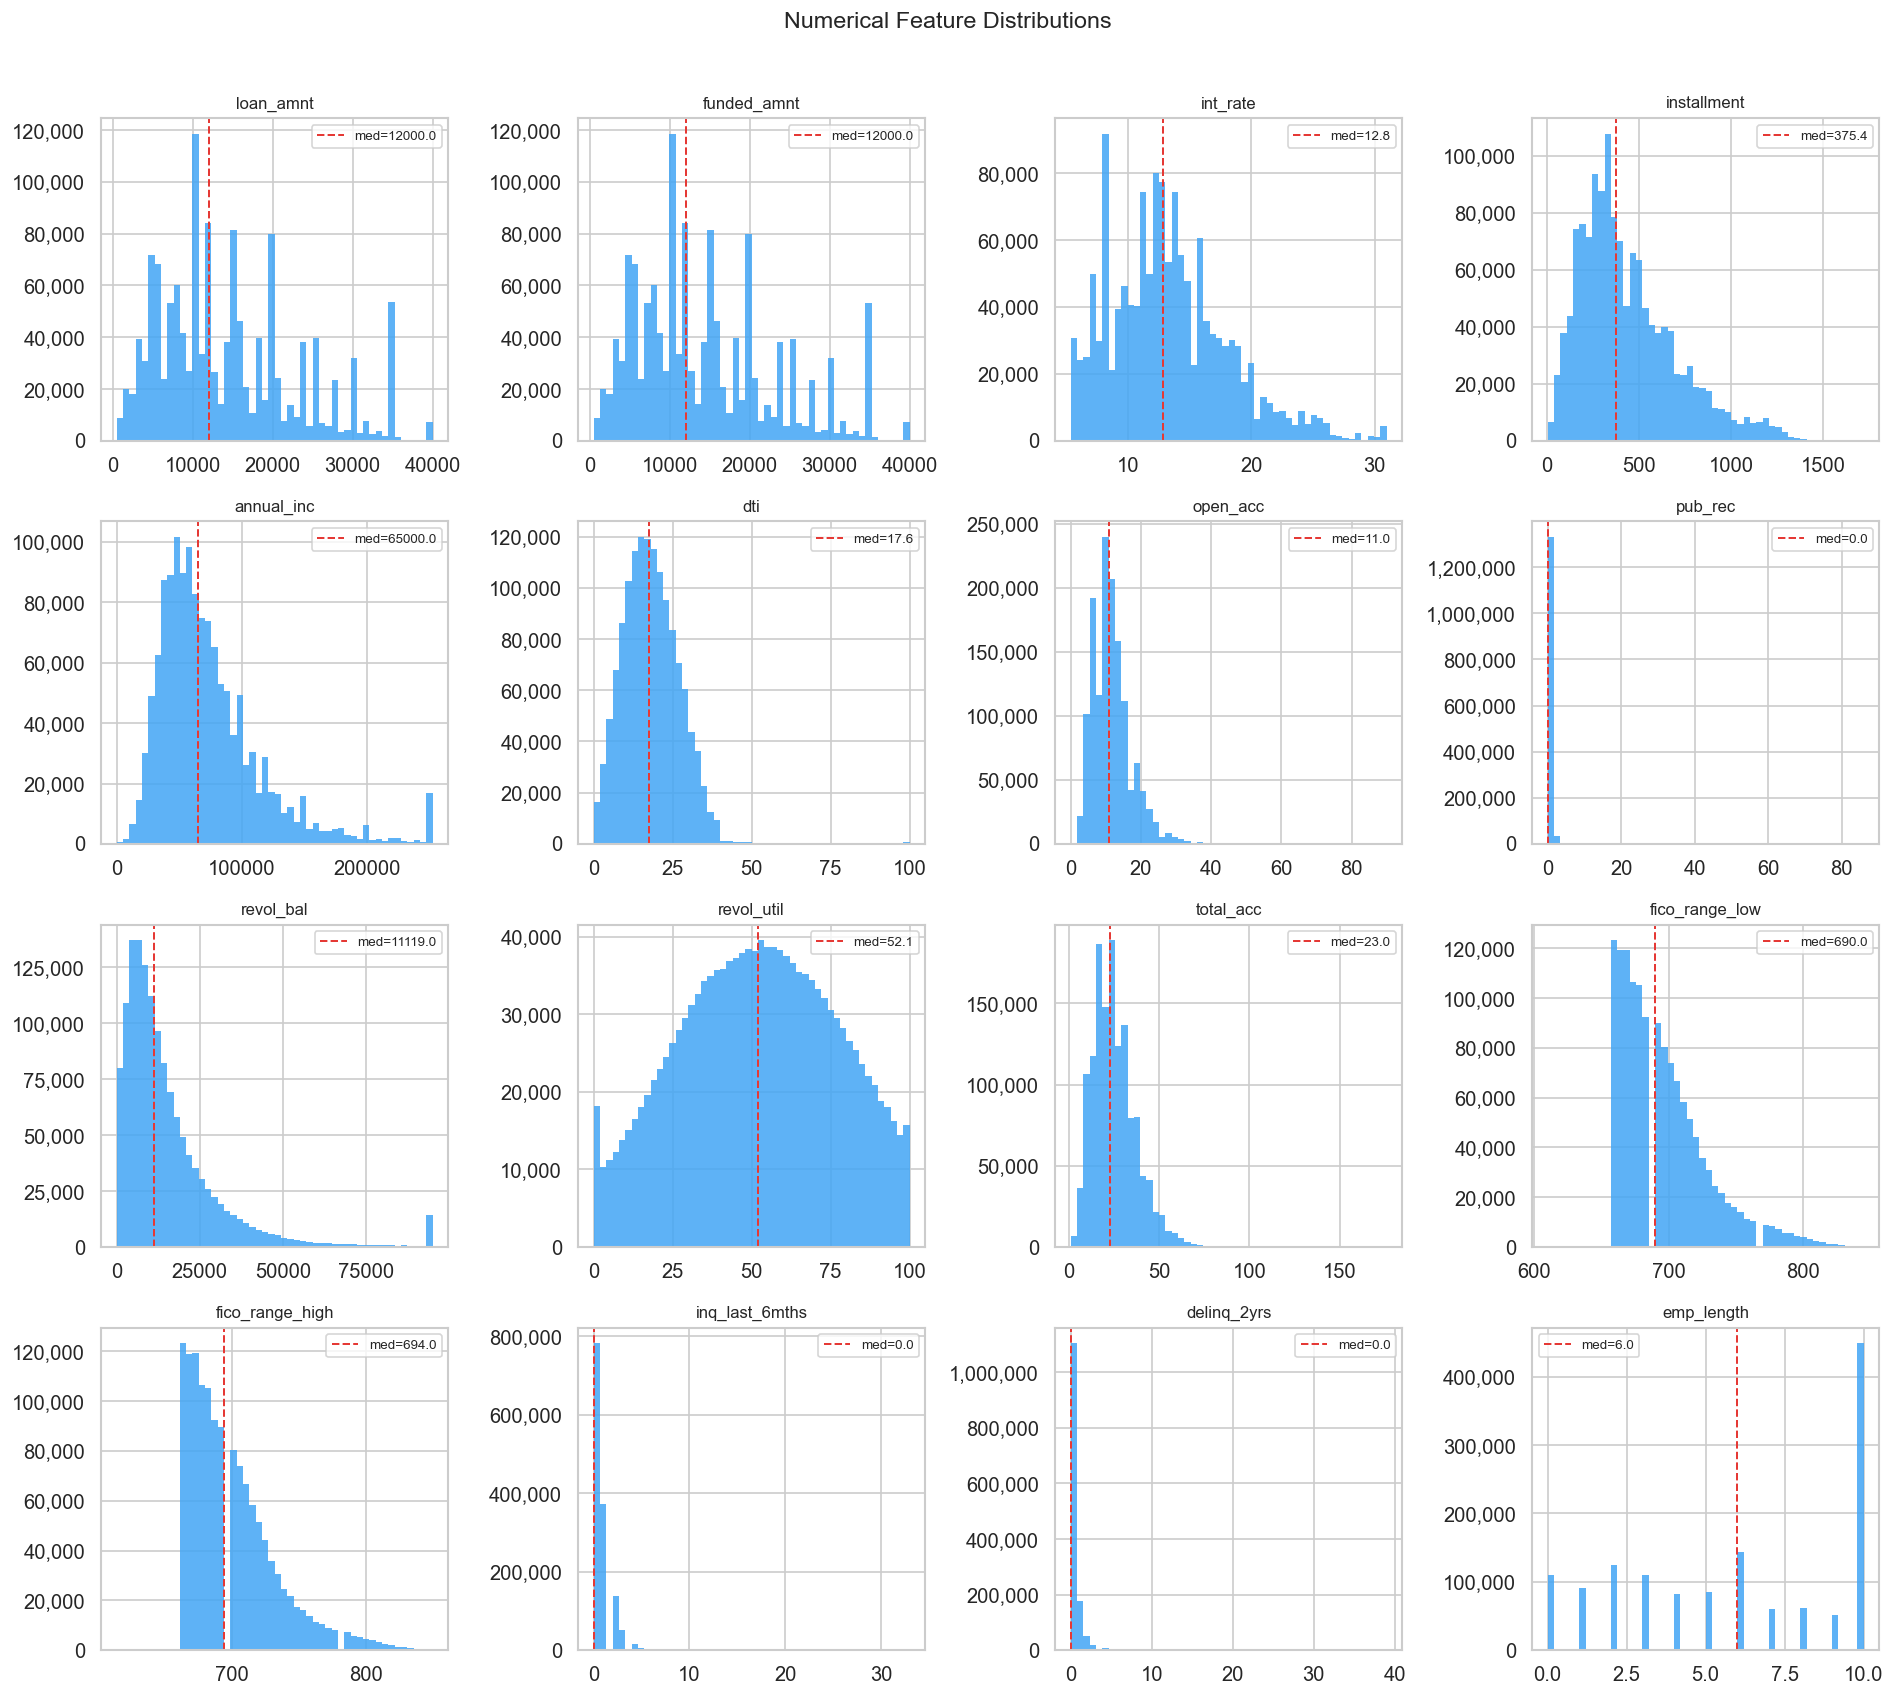

In [7]:
# Key numeric features to focus on — adjust as needed
KEY_NUM_FEATURES = [
    "loan_amnt", "funded_amnt", "int_rate", "installment",
    "annual_inc", "dti", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "fico_range_low", "fico_range_high",
    "inq_last_6mths", "delinq_2yrs", "emp_length",
]
# Keep only those that exist in the dataframe
KEY_NUM_FEATURES = [c for c in KEY_NUM_FEATURES if c in df.columns]

n = len(KEY_NUM_FEATURES)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(KEY_NUM_FEATURES):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, edgecolor="none", color="#42A5F5", alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    # Mark median
    med = data.median()
    axes[i].axvline(med, color="#E53935", ls="--", lw=1.2, label=f"med={med:.1f}")
    axes[i].legend(fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

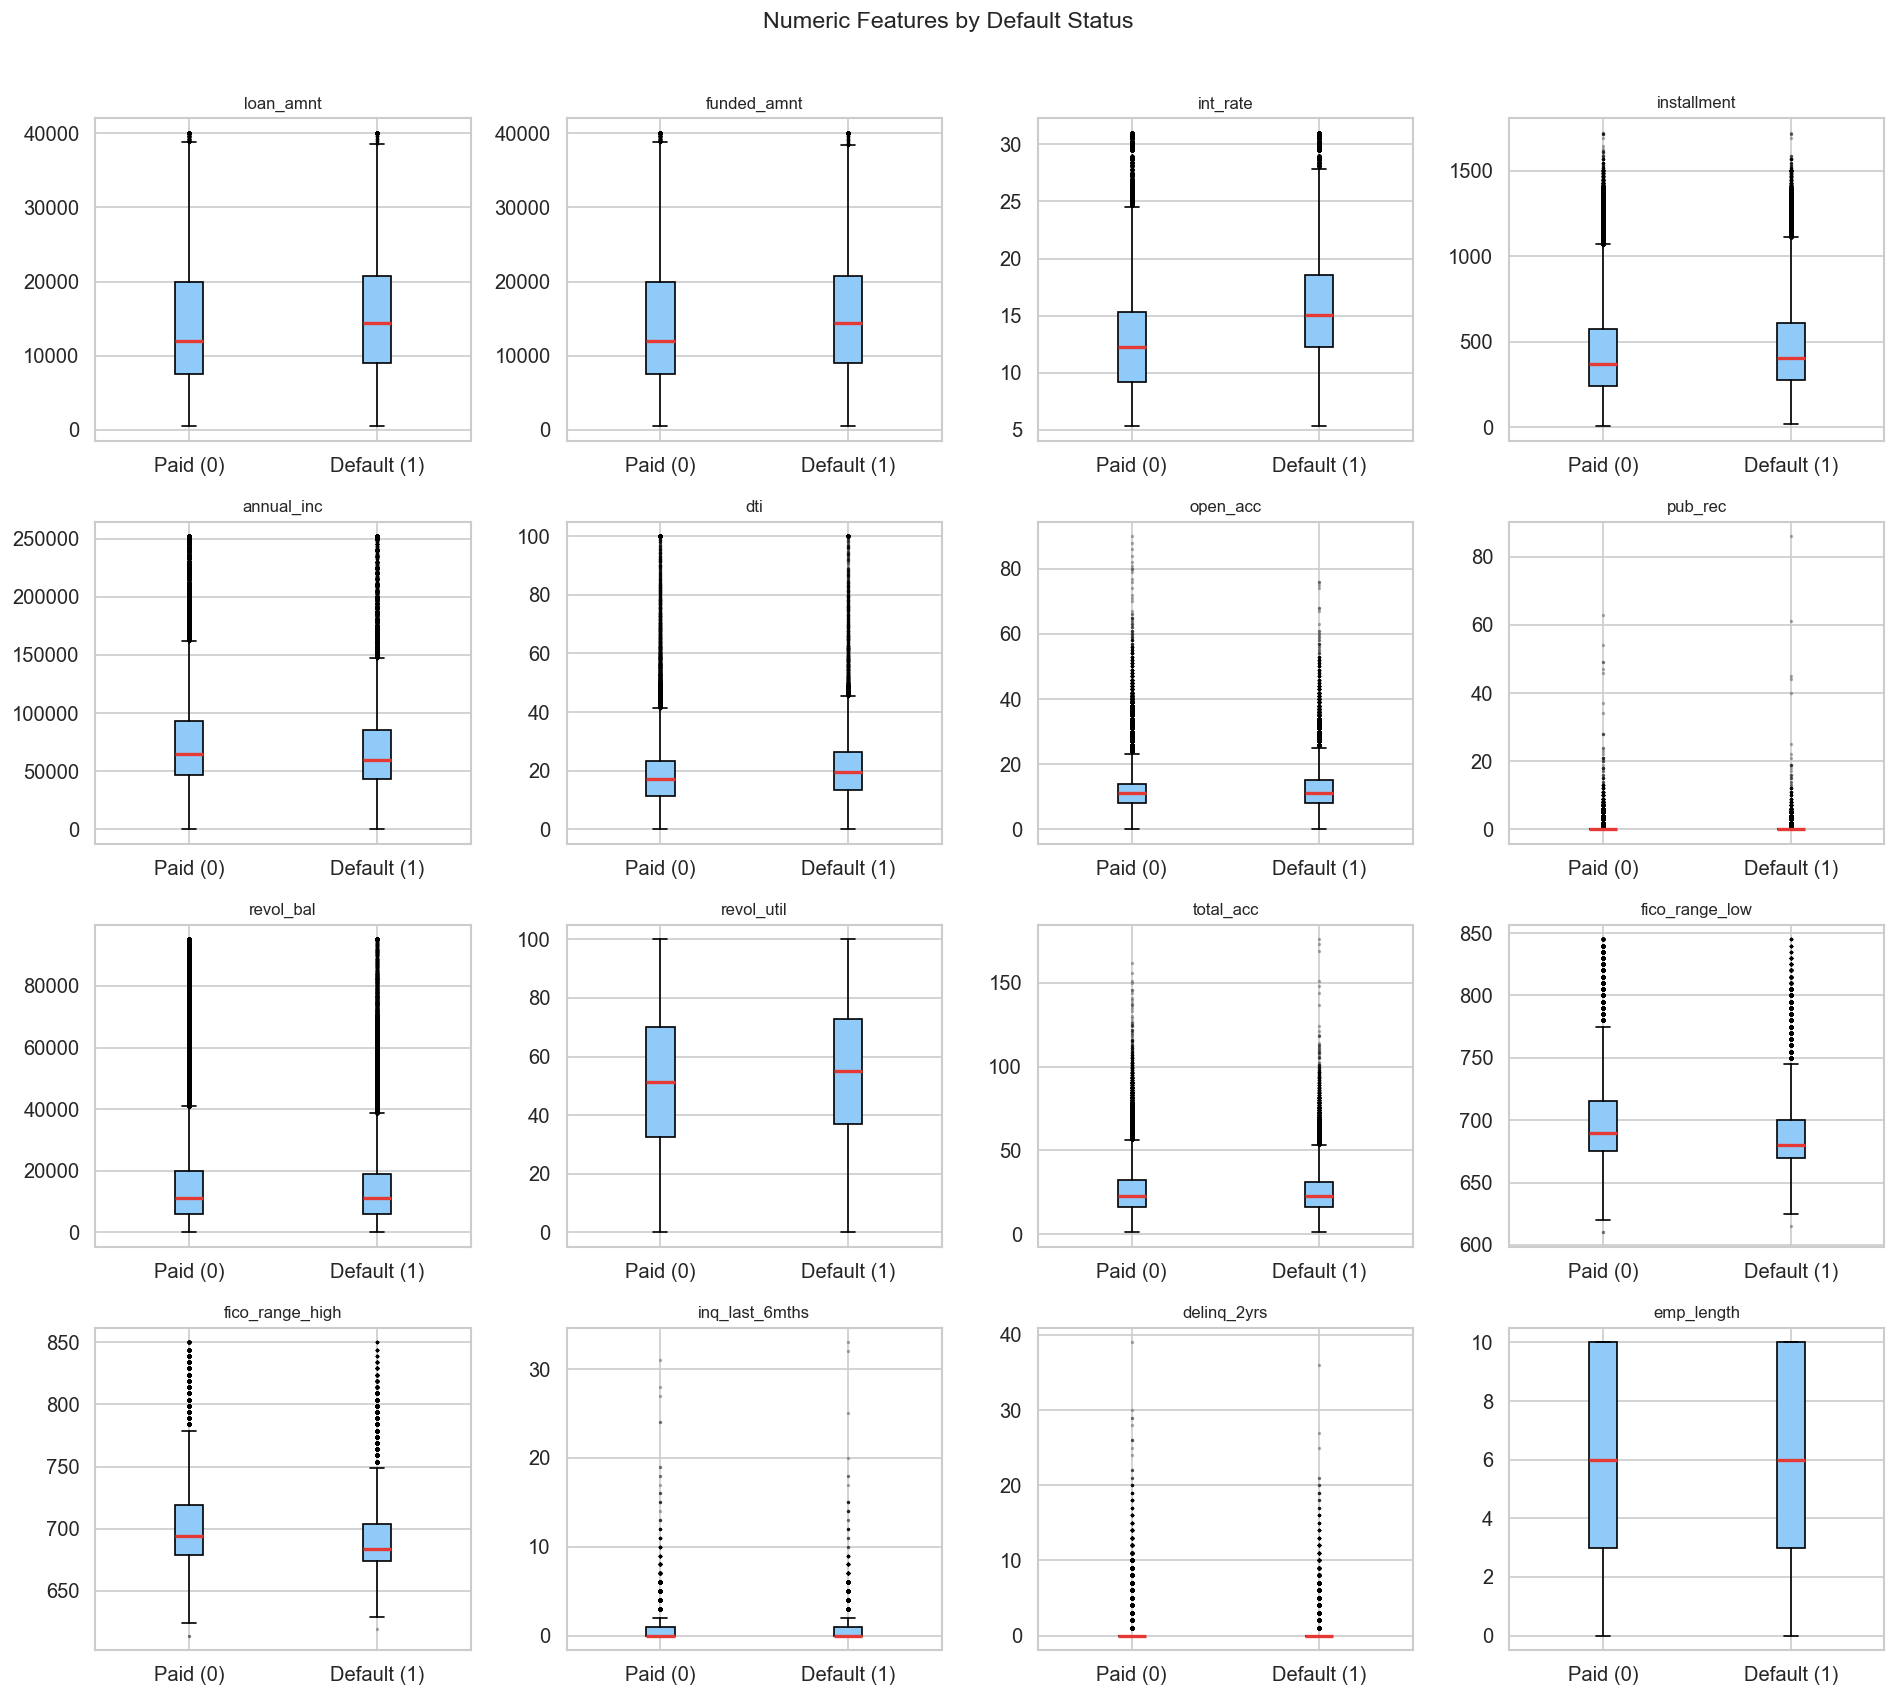

In [8]:
# Box plots: numeric features by target
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(KEY_NUM_FEATURES):
    subset = df[[col, TARGET]].dropna()
    groups = [subset.loc[subset[TARGET] == v, col].values for v in [0, 1]]
    axes[i].boxplot(groups, labels=["Paid (0)", "Default (1)"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#90CAF9"),
                    medianprops=dict(color="#E53935", lw=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Features by Default Status", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 6. Categorical Features — Value Counts <a id="6"></a>

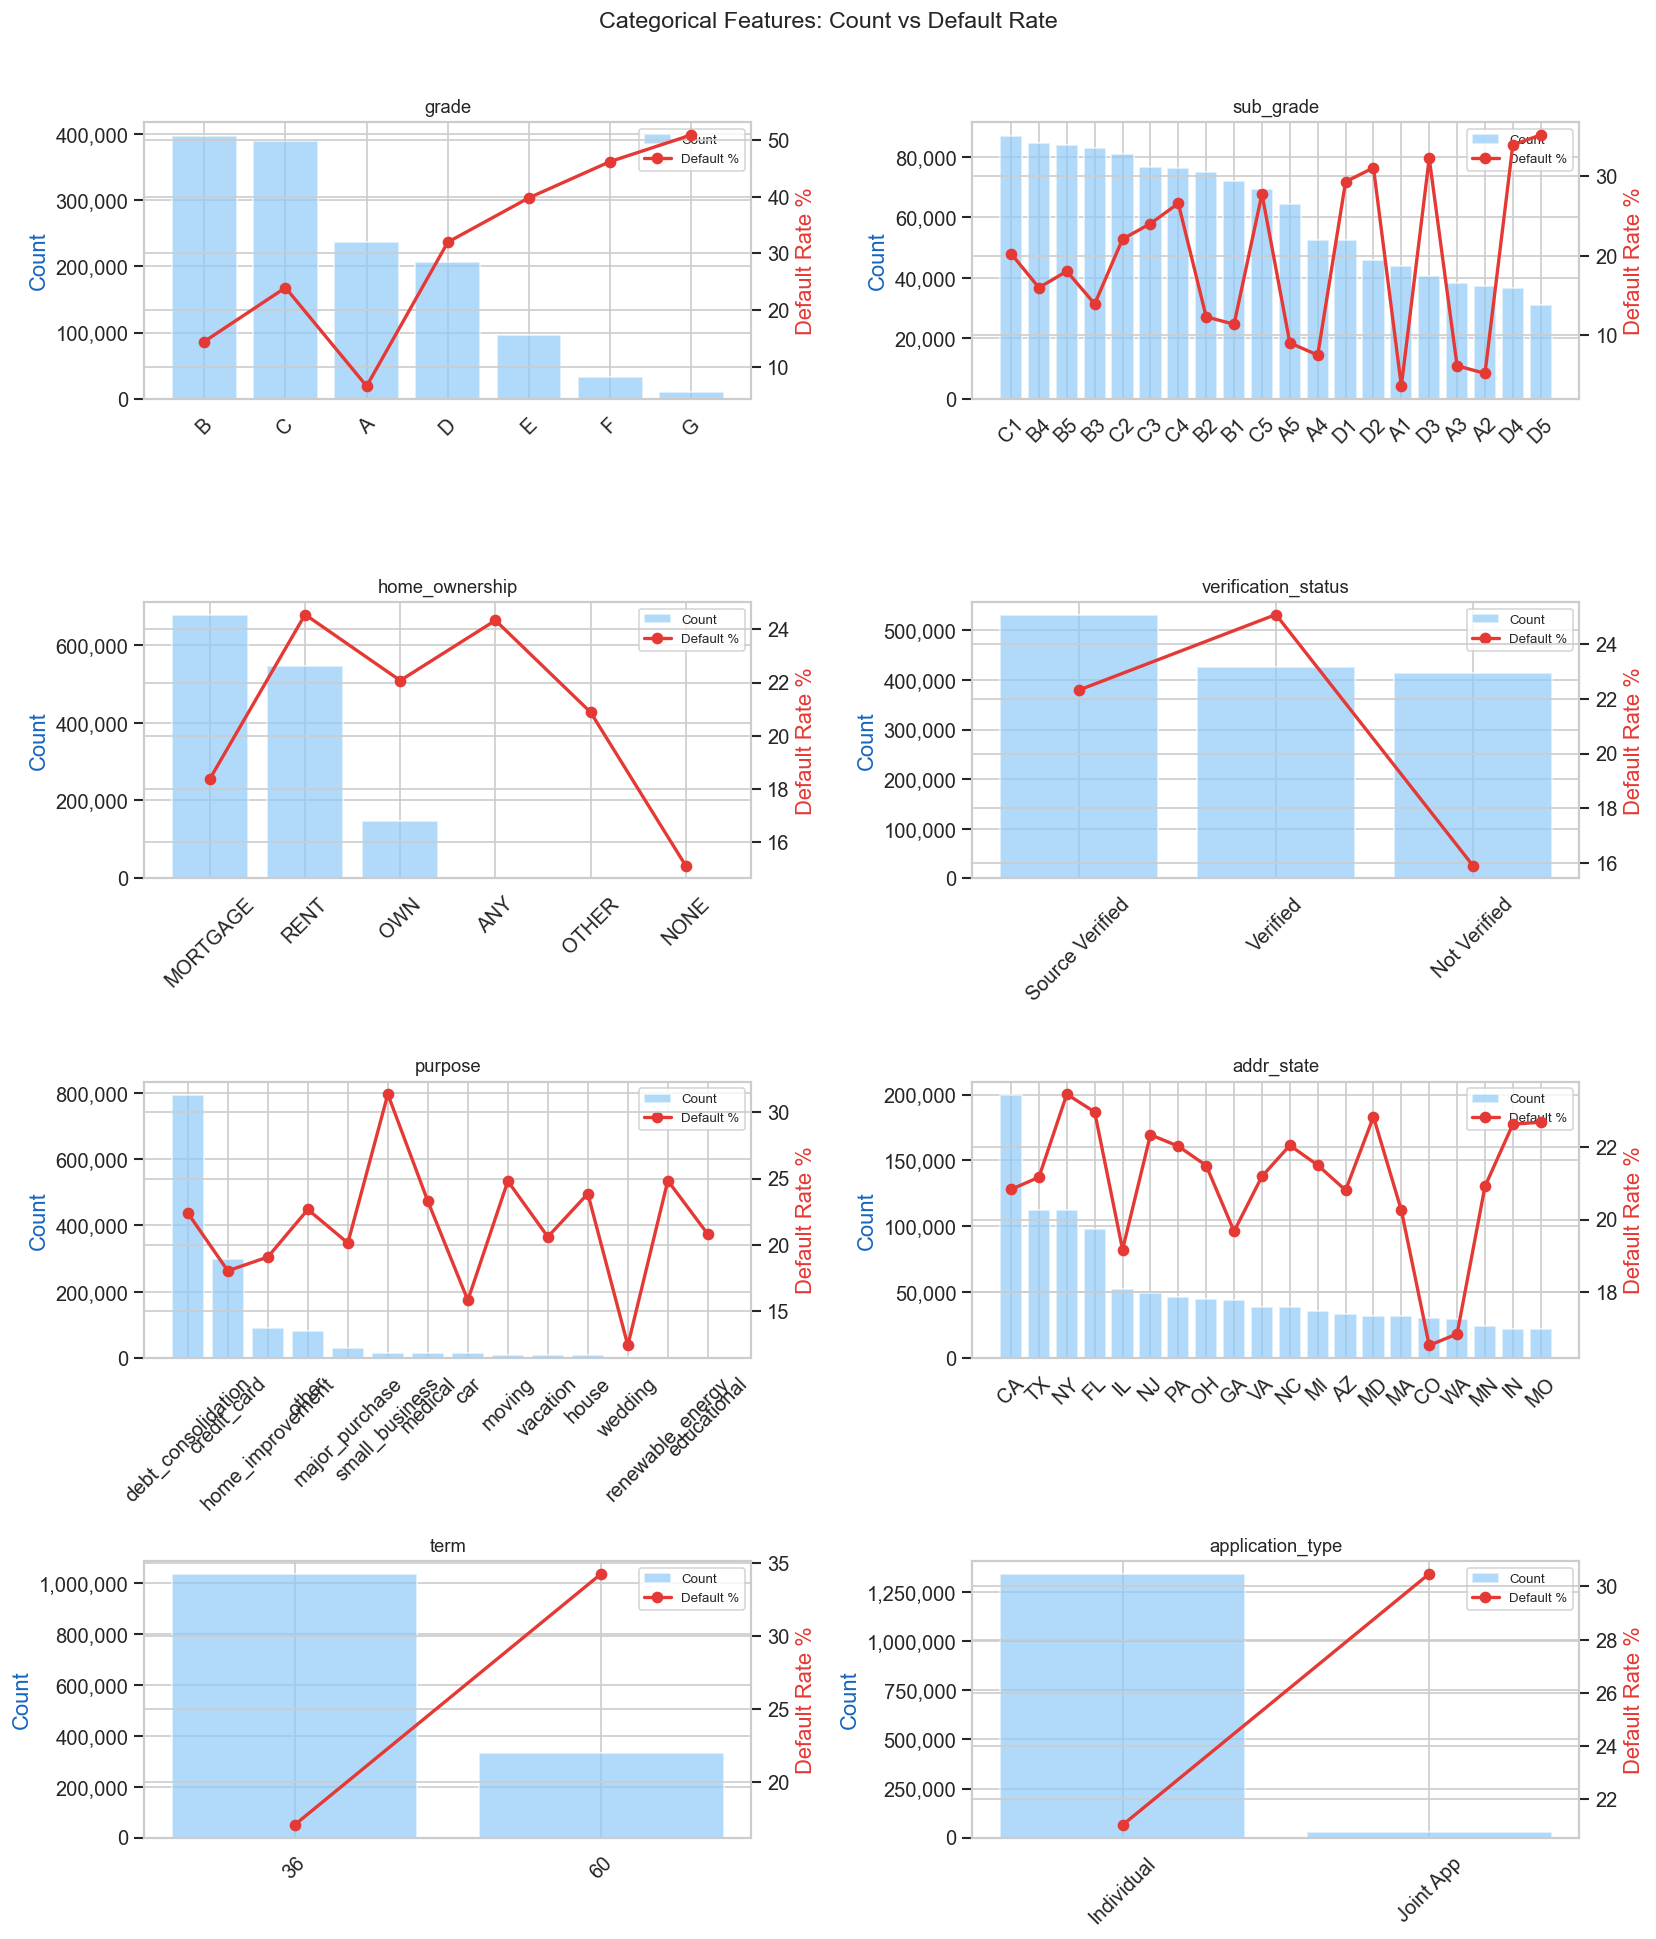

In [9]:
KEY_CAT_FEATURES = [
    "grade", "sub_grade", "home_ownership", "verification_status",
    "purpose", "addr_state", "term", "application_type",
]
KEY_CAT_FEATURES = [c for c in KEY_CAT_FEATURES if c in df.columns]

ncols = 2
nrows = (len(KEY_CAT_FEATURES) + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

palette_def = {"0": "#4CAF50", "1": "#F44336", 0: "#4CAF50", 1: "#F44336"}

for i, col in enumerate(KEY_CAT_FEATURES):
    cross = (
        df.groupby(col)[TARGET]
        .agg(["sum", "count"])
        .assign(default_rate=lambda x: x["sum"] / x["count"] * 100)
        .sort_values("count", ascending=False)
        .head(20)           # top-20 categories for readability
    )
    ax2 = axes[i].twinx()
    axes[i].bar(cross.index.astype(str), cross["count"],
                color="#90CAF9", alpha=0.7, label="Count")
    ax2.plot(cross.index.astype(str), cross["default_rate"],
             color="#E53935", marker="o", lw=2, label="Default %")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Count", color="#1565C0")
    ax2.set_ylabel("Default Rate %", color="#E53935")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    lines1, labs1 = axes[i].get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    axes[i].legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper right")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Features: Count vs Default Rate", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


## 7. Correlation Analysis <a id="7"></a>

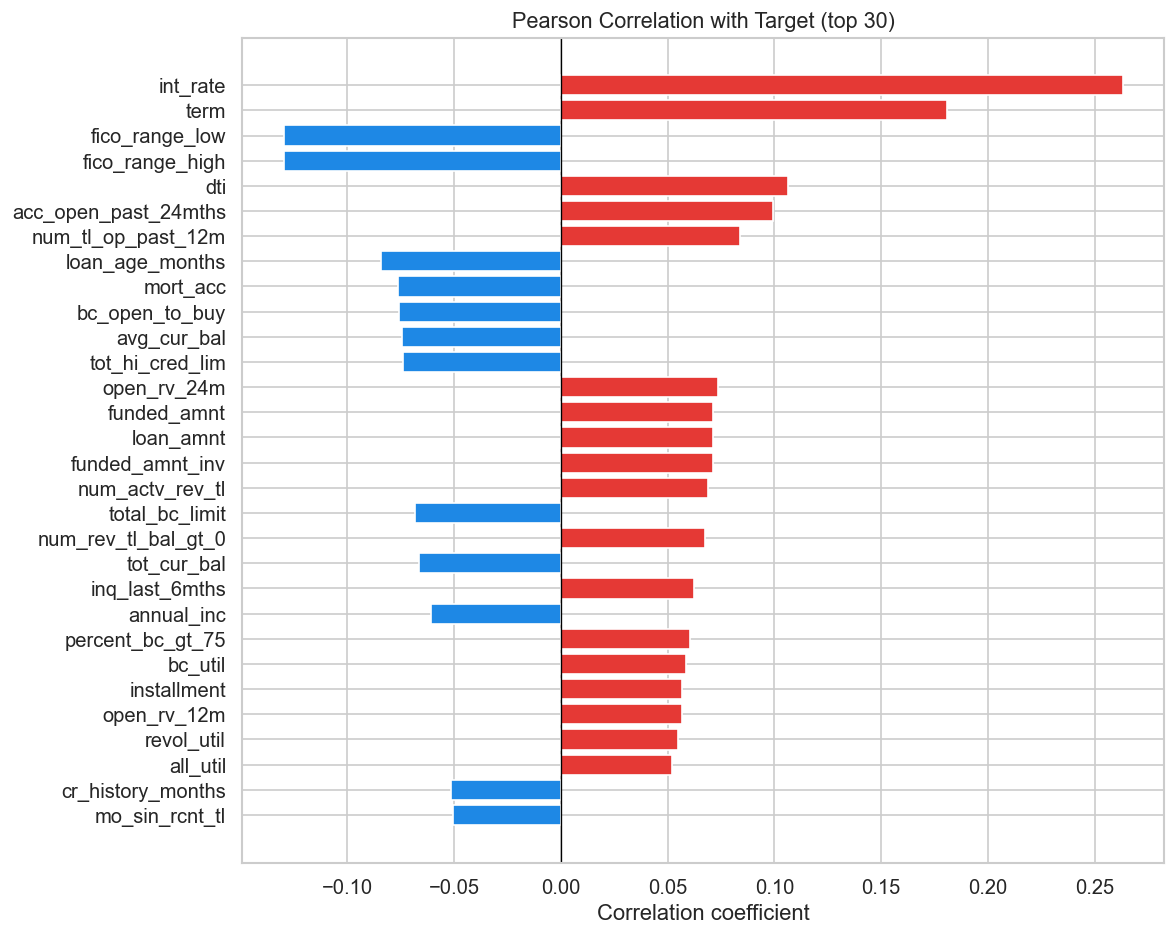


Top 10 positive correlates:


,corr_with_default
int_rate,0.263009
term,0.180987
fico_range_low,-0.129576
fico_range_high,-0.129575
dti,0.106571
acc_open_past_24mths,0.099426
num_tl_op_past_12m,0.084071
loan_age_months,-0.083977
mort_acc,-0.076273
bc_open_to_buy,-0.075805



Top 10 negative correlates:


,corr_with_default
inq_last_6mths,0.062479
annual_inc,-0.060561
percent_bc_gt_75,0.060554
bc_util,0.058481
installment,0.056614
open_rv_12m,0.056575
revol_util,0.054880
all_util,0.051962
cr_history_months,-0.051454
mo_sin_rcnt_tl,-0.050607


In [10]:
# Correlation of numeric features with target
# TARGET is already in num_cols; duplicating it makes .corr()[TARGET] a DataFrame and breaks .sort_values
_corr_cols = list(dict.fromkeys(num_cols + [TARGET]))
corr_with_target = (
    df[_corr_cols]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#E53935" if v > 0 else "#1E88E5" for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Pearson Correlation with Target (top 30)", fontsize=13)
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print("\nTop 10 positive correlates:")
display(corr_with_target.head(10).to_frame("corr_with_default"))
print("\nTop 10 negative correlates:")
display(corr_with_target.tail(10).to_frame("corr_with_default"))

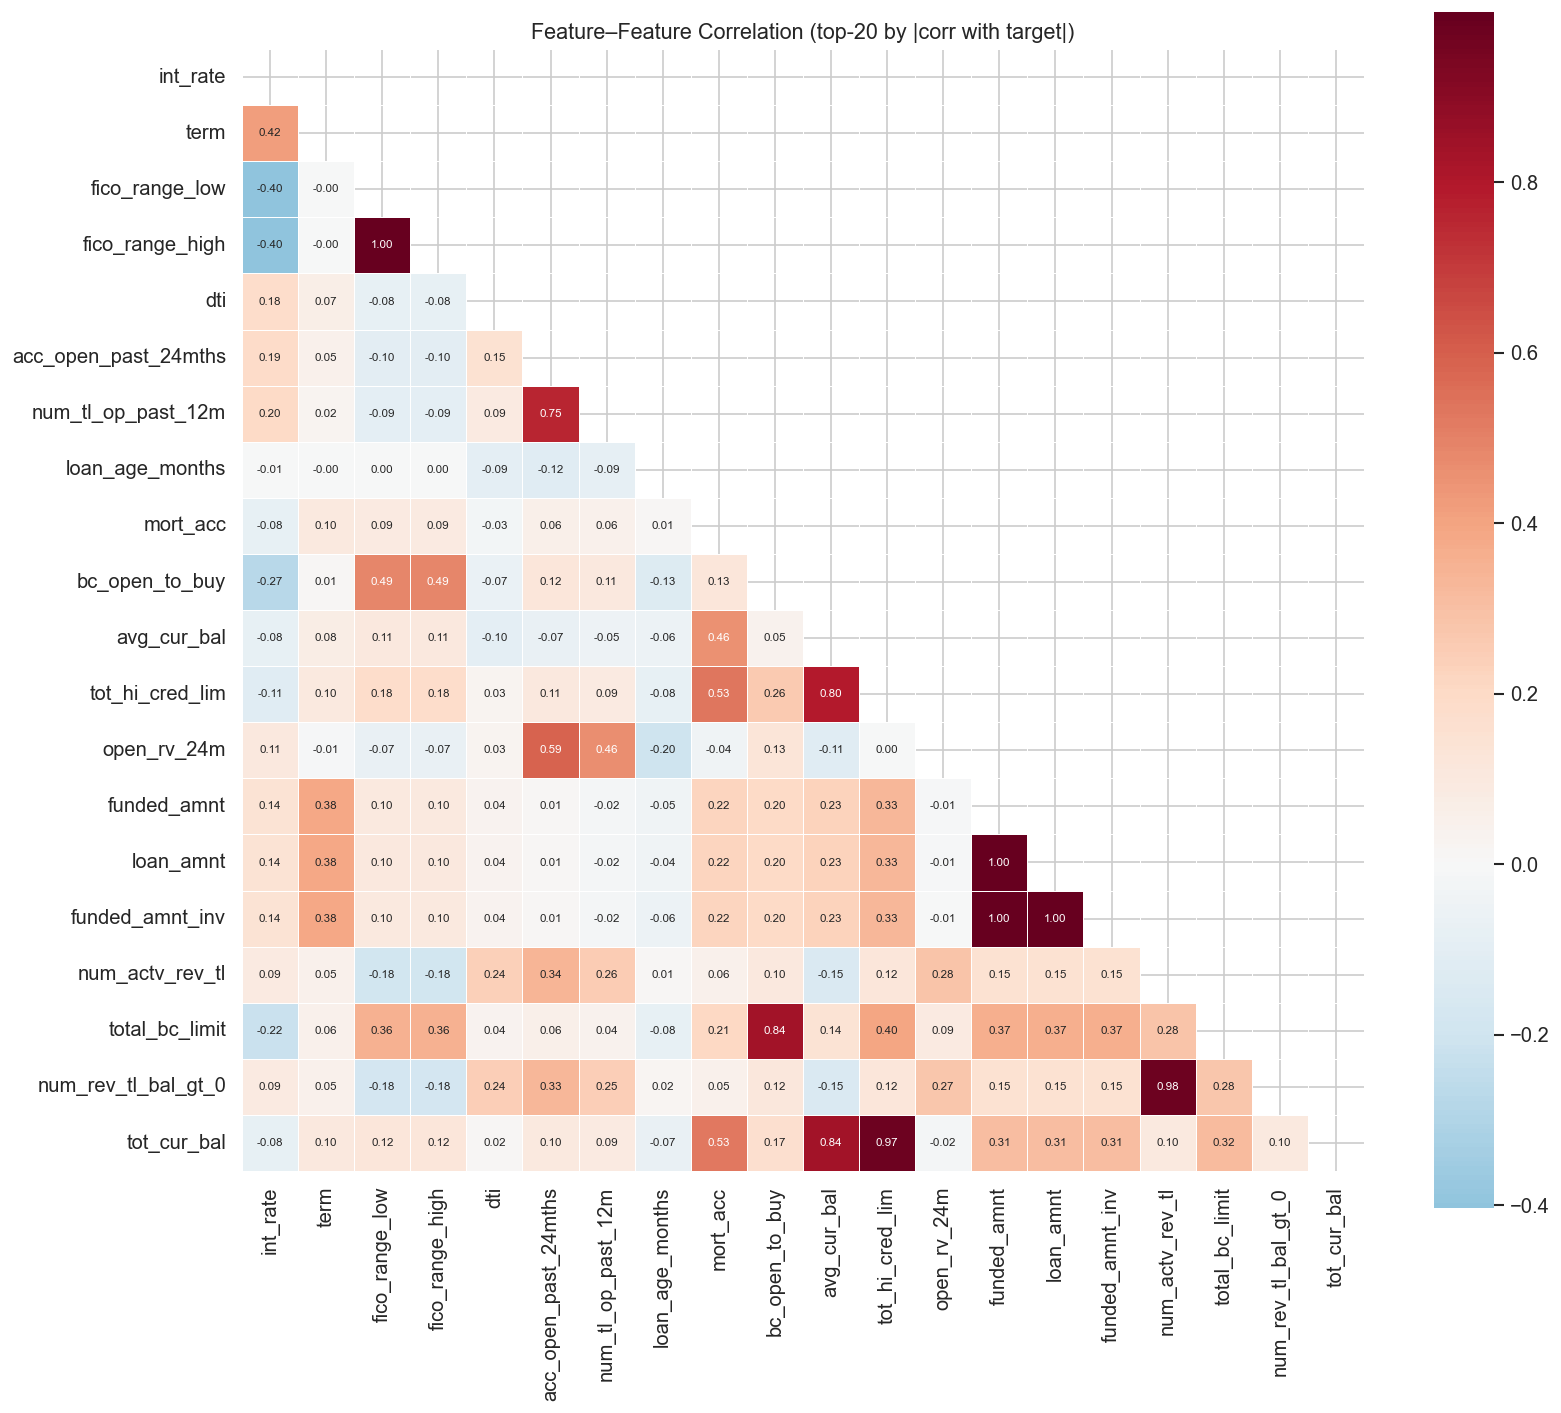

In [11]:
# Inter-feature correlation heatmap (top-20 most correlated with target)
top_features = corr_with_target.head(20).index.tolist()
corr_matrix  = df[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature–Feature Correlation (top-20 by |corr with target|)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature vs Target Relationships <a id="8"></a>

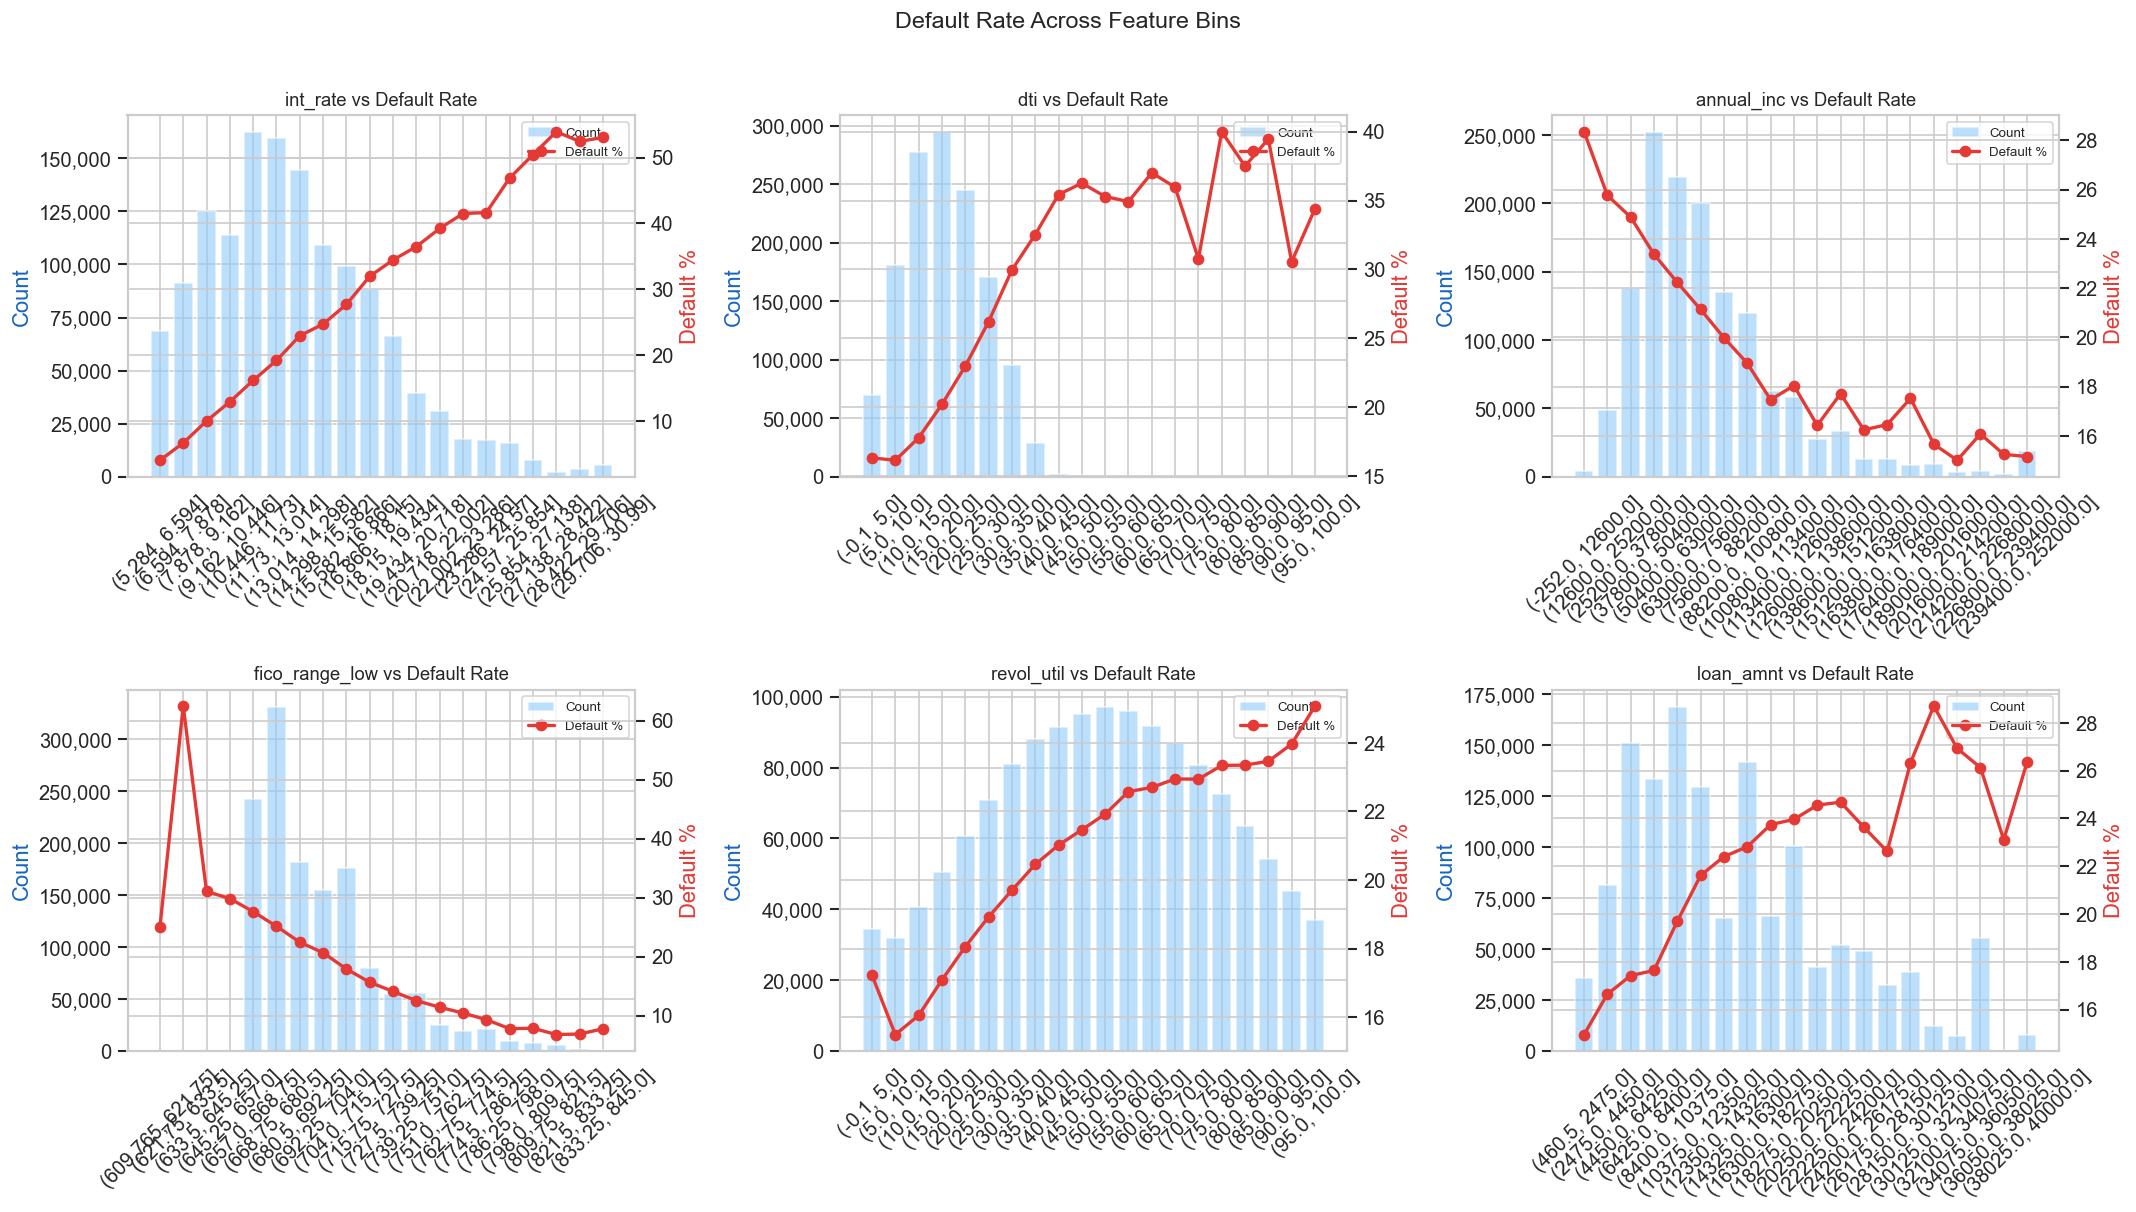

In [12]:
def default_rate_by_bin(col, n_bins=20):
    """Bin a numeric column and compute default rate per bin."""
    binned = pd.cut(df[col].dropna(), bins=n_bins)
    result = df.loc[df[col].notna()].groupby(binned, observed=True)[TARGET].agg(
        default_rate="mean", count="count"
    )
    result["default_rate"] *= 100
    return result

SPOTLIGHT = ["int_rate", "dti", "annual_inc", "fico_range_low", "revol_util", "loan_amnt"]
SPOTLIGHT = [c for c in SPOTLIGHT if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(SPOTLIGHT):
    try:
        binned_df = default_rate_by_bin(col)
        x_labels  = [str(iv) for iv in binned_df.index]
        ax2 = axes[i].twinx()
        axes[i].bar(x_labels, binned_df["count"], color="#90CAF9", alpha=0.6, label="Count")
        ax2.plot(x_labels, binned_df["default_rate"], color="#E53935",
                 marker="o", lw=2, label="Default %")
        axes[i].set_title(f"{col} vs Default Rate", fontsize=11)
        axes[i].set_ylabel("Count", color="#1565C0")
        ax2.set_ylabel("Default %", color="#E53935")
        axes[i].tick_params(axis="x", rotation=45)
        axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        lines1, labs1 = axes[i].get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        axes[i].legend(lines1 + lines2, labs1 + labs2, fontsize=8)
    except Exception as e:
        axes[i].set_title(f"{col} — skipped: {e}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Default Rate Across Feature Bins", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

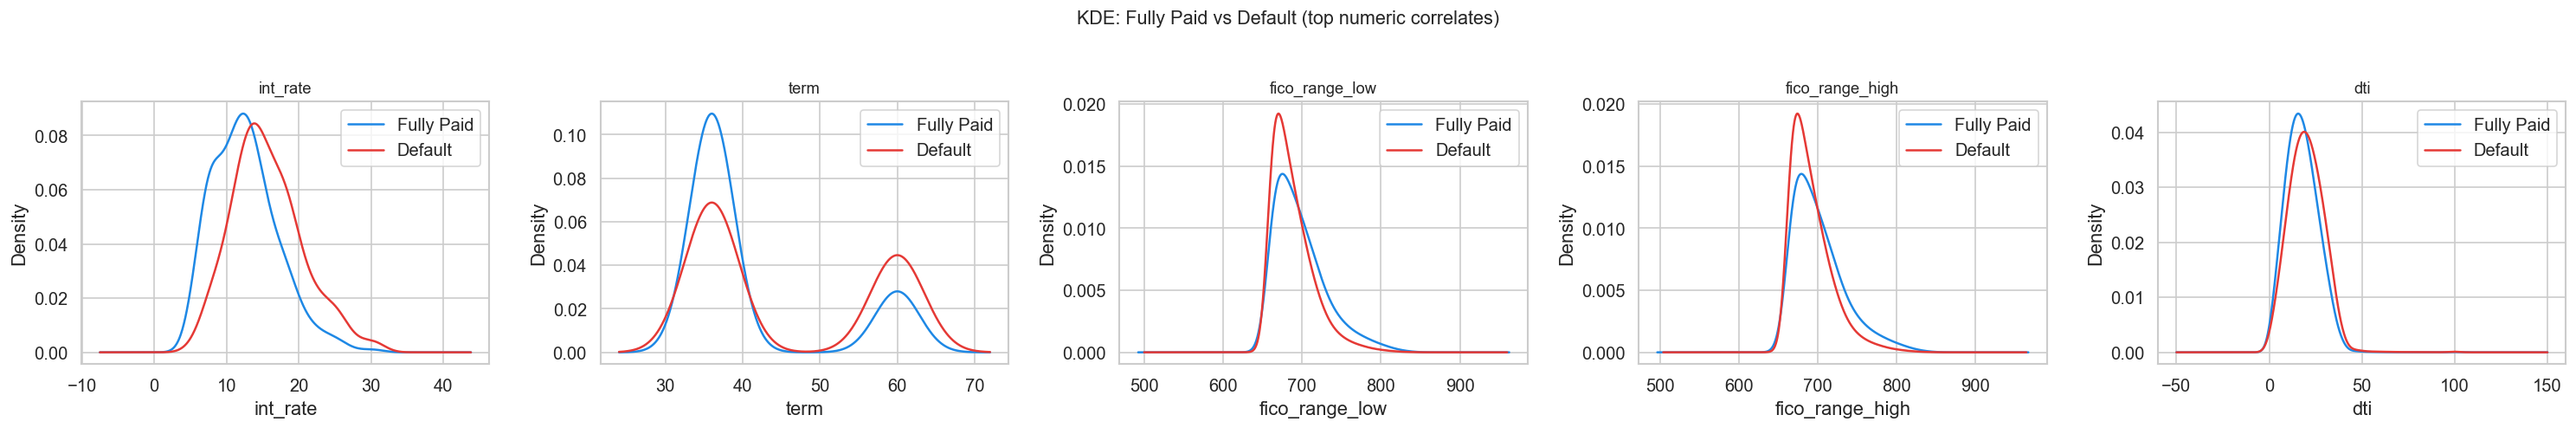

In [13]:
# KDE overlays: paid vs default, for top numeric correlates
top5_num = [c for c in corr_with_target.head(5).index if c in df.columns]

fig, axes = plt.subplots(1, len(top5_num), figsize=(5 * len(top5_num), 4))
if len(top5_num) == 1:
    axes = [axes]

for ax, col in zip(axes, top5_num):
    for label, color, name in [(0, "#1E88E5", "Fully Paid"), (1, "#E53935", "Default")]:
        data = df.loc[df[TARGET] == label, col].dropna()
        data.plot.kde(ax=ax, color=color, label=name, bw_method=0.3)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle("KDE: Fully Paid vs Default (top numeric correlates)", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Key Insights <a id="9"></a>

In [14]:
print("=" * 60)
print("  EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

# Class imbalance
print(f"\n[Target]")
print(f"  Default rate         : {df[TARGET].mean()*100:.2f}%  (class imbalance ~{100/df[TARGET].mean():.0f}:1)")

# Missing values
print(f"\n[Missing Values]")
print(f"  Columns with any NaN : {(df.isna().any()).sum()}")
print(f"  Columns >5% missing  : {(df.isna().mean() > 0.05).sum()}")

# Numeric range issues (potential outliers)
print(f"\n[Notable Outliers / Skew]")
skewed = df[num_cols].skew().sort_values(ascending=False).head(5)
print(skewed.to_string())

# Top correlates with target
print(f"\n[Strongest Correlates with Default]")
print(corr_with_target.head(10).to_string())

# Cardinality of categorical columns
if cat_cols:
    print(f"\n[Categorical Cardinality]")
    card = df[cat_cols].nunique().sort_values(ascending=False)
    print(card.to_string())

print("\n[Next Steps]")
print("  - Feature engineering: encode grade/sub_grade numerically")
print("  - Address class imbalance with SMOTE or class_weight='balanced'")
print("  - Check collinear numeric features (loan_amnt ~ funded_amnt ~ installment)")
print("  - Consider log-transform for highly skewed features (annual_inc, revol_bal)")
print("  - int_rate and fico_range_low are strong discriminators — keep in baseline")
print("=" * 60)

  EDA SUMMARY — KEY FINDINGS

[Target]
  Default rate         : 21.23%  (class imbalance ~471:1)

[Missing Values]
  Columns with any NaN : 0
  Columns >5% missing  : 0

[Notable Outliers / Skew]
tot_coll_amt        689.293457
delinq_amnt          94.828941
total_rev_hi_lim     52.524021
num_tl_120dpd_2m     47.748295
tax_liens            33.543316

[Strongest Correlates with Default]
int_rate                0.263009
term                    0.180987
fico_range_low         -0.129576
fico_range_high        -0.129575
dti                     0.106571
acc_open_past_24mths    0.099426
num_tl_op_past_12m      0.084071
loan_age_months        -0.083977
mort_acc               -0.076273
bc_open_to_buy         -0.075805

[Categorical Cardinality]
emp_title              383314
addr_state                 51
sub_grade                  35
purpose                    14
grade                       7
home_ownership              6
verification_status         3
initial_list_status         2
application_typ